In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv("volunteer_data.csv")
df.head()

,Volunteer_ID,Age,City,Event,Hours_Contributed,Previous_Participation,Training_Attended,Participated_Next_Event
0,1,28,Pune,Education Drive,10,3,Yes,1
1,2,20,Pune,Education Drive,20,6,Yes,1
2,3,18,Pune,Food Distribution,9,8,Yes,1
3,4,26,Mumbai,Health Camp,9,7,No,1
4,5,30,Pune,Food Distribution,15,5,No,1


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Volunteer_ID             100 non-null    int64 
 1   Age                      100 non-null    int64 
 2   City                     100 non-null    object
 3   Event                    100 non-null    object
 4   Hours_Contributed        100 non-null    int64 
 5   Previous_Participation   100 non-null    int64 
 6   Training_Attended        100 non-null    object
 7   Participated_Next_Event  100 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 6.4+ KB


,Volunteer_ID,Age,Hours_Contributed,Previous_Participation,Participated_Next_Event
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,23.680000,11.250000,4.580000,0.910000
std,29.011492,3.953978,5.211438,2.609927,0.287623
min,1.000000,18.000000,3.000000,0.000000,0.000000
25%,25.750000,20.000000,7.000000,2.750000,1.000000
50%,50.500000,23.500000,11.000000,5.000000,1.000000
75%,75.250000,27.000000,15.000000,7.000000,1.000000
max,100.000000,30.000000,20.000000,8.000000,1.000000


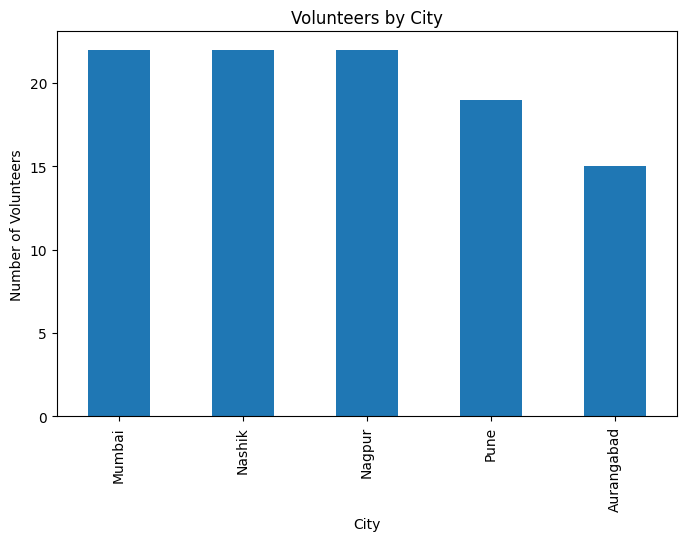

In [ ]:
plt.figure(figsize=(8,5))
df['City'].value_counts().plot(kind='bar')
plt.title("Volunteers by City")
plt.xlabel("City")
plt.ylabel("Number of Volunteers")
plt.show()

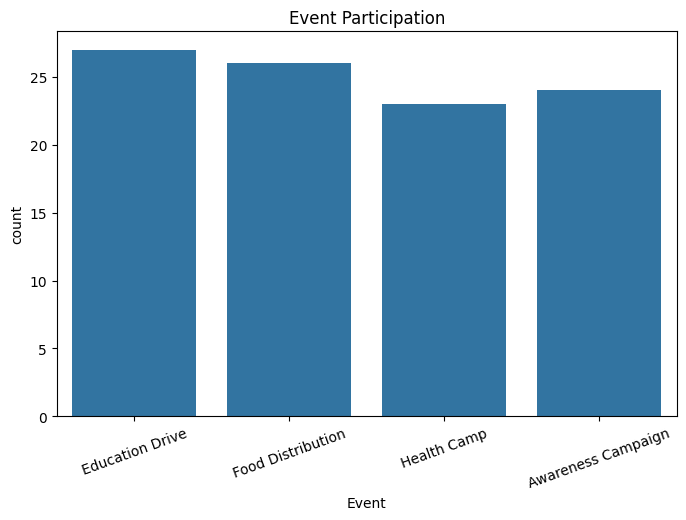

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Event'
)
plt.xticks(rotation=20)
plt.title("Event Participation")
plt.show()

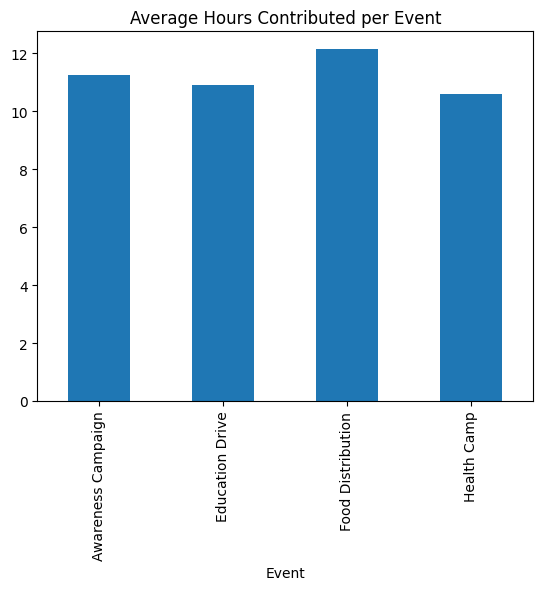

In [ ]:
avg_hours = df.groupby(
    'Event'
)['Hours_Contributed'].mean()
avg_hours.plot(kind='bar')
plt.title("Average Hours Contributed per Event")
plt.show()

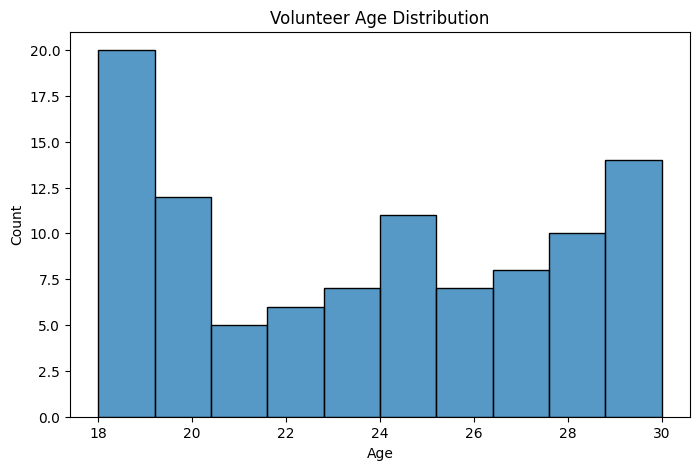

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Age'],
    bins=10
)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Volunteer Age Distribution")
plt.show()

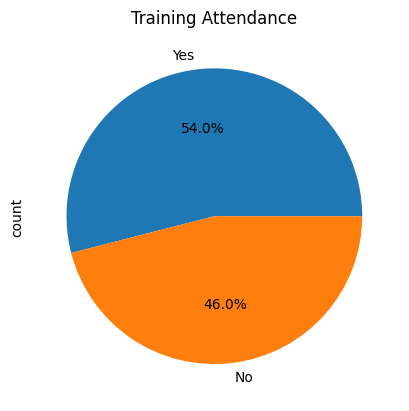

In [ ]:
df['Training_Attended'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Training Attendance")
plt.show()

In [ ]:
df['Training_Attended'] = df[
    'Training_Attended'
].map({
    'Yes':1,
    'No':0
})

In [ ]:
X = df[
    [
        'Age',
        'Hours_Contributed',
        'Previous_Participation',
        'Training_Attended'
    ]
]
y = df['Participated_Next_Event']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression()

# Impute NaN values in 'Training_Attended' column of X_train and X_test with 0
# This assumes that if a value became NaN after mapping 'Yes':1, 'No':0,
# it should be treated as 'No' (0).
X_train['Training_Attended'] = X_train['Training_Attended'].fillna(0)
X_test['Training_Attended'] = X_test['Training_Attended'].fillna(0)

model.fit(
    X_train,
    y_train
)
predictions = model.predict(
    X_test
)

In [ ]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print(
    "Model Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

Model Accuracy: 95.0 %


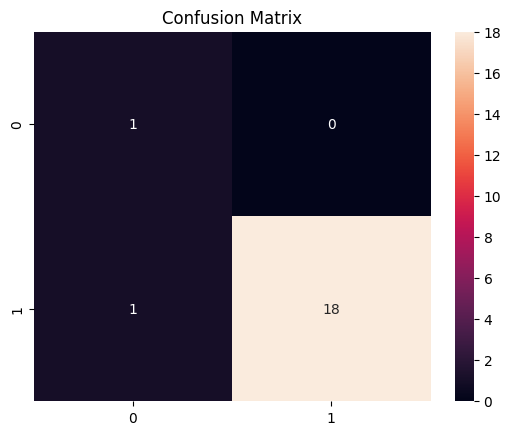

In [ ]:
cm = confusion_matrix(
    y_test,
    predictions
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def recommend(row):
    if (
        row['Hours_Contributed'] > 10
        and row['Previous_Participation'] > 3
    ):
        return "Highly Engaged"
    return "Needs Encouragement"
df['Volunteer_Status'] = df.apply(
    recommend,
    axis=1
)
df[
    [
        'Volunteer_ID',
        'Volunteer_Status'
    ]
].head()

,Volunteer_ID,Volunteer_Status
0,1,Needs Encouragement
1,2,Highly Engaged
2,3,Needs Encouragement
3,4,Needs Encouragement
4,5,Highly Engaged


# Conclusion

This project demonstrates how Data Analytics, Machine Learning, and Artificial Intelligence can support NGO operations.

Key Findings:

- Volunteer participation varies across cities.
- Certain events attract higher engagement.
- Training attendance positively influences future participation.
- Machine Learning can predict volunteer engagement.
- AI recommendations can help identify highly engaged volunteers.

The system can help NayePankh Foundation improve volunteer management, increase participation, and make data-driven decisions.